In [6]:
# Standard library imports for logging, paths, and environment variables.
import logging
import os
import sys
from pathlib import Path

# PyTorch core library.
import torch
from dotenv import load_dotenv
from google.colab import userdata

# Project helpers used by the EffNetB0 training notebook.
from pytorch_engine import (
    create_csv_dataloader,
    download_and_prepare_kaggle_ham10000_dataset,
    get_current_device,
    set_seeds,
    get_train_transform,
    create_milestone_checkpoint_callback,
)
from pytorch_engine.data_split import split_csv_metadata
from pytorch_engine.models import create_effnetb0_model
from pytorch_engine.training_loop import train_model
from pytorch_engine.visualization import plot_loss_curves


In [7]:
# Inspect available GPU memory before training.
# This helps us decide whether the chosen batch size is realistic.
if torch.cuda.is_available():
    total_free_gpu_memory, total_gpu_memory = torch.cuda.mem_get_info()
    print(f"Total free GPU memory: {round(total_free_gpu_memory * 1e-9, 3)} GB")
    print(f"Total GPU memory: {round(total_gpu_memory * 1e-9, 3)} GB")
else:
    print("CUDA not available. Running on CPU; GPU memory stats skipped.")


Total free GPU memory: 23.456 GB
Total GPU memory: 23.659 GB


In [8]:
# Check GPU architecture so we can enable newer CUDA math paths when supported.
# TF32 is useful on Ampere+ GPUs and often improves training throughput.
if torch.cuda.is_available():
    GPU_SCORE = torch.cuda.get_device_capability()
    print(f"GPU capability score: {GPU_SCORE}")
    if GPU_SCORE >= (8, 0):
        print("Ampere+ GPU detected. Enabling TF32 matmul path.")
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        torch.set_float32_matmul_precision("high")
    else:
        print("Pre-Ampere GPU detected. TF32 path unavailable.")
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
else:
    GPU_SCORE = None
    torch.backends.cuda.matmul.allow_tf32 = False
    print("CUDA not available. TF32 and CUDA compile speedups disabled.")


GPU capability score: (8, 9)
Ampere+ GPU detected. Enabling TF32 matmul path.


In [9]:
# Resolve pytorch-engine root and load HF credentials from apps/pytorch-engine/.env.
def _find_pytorch_engine_root() -> Path | None:
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        pp = d / "pyproject.toml"
        if not pp.is_file():
            continue
        try:
            if 'name = "pytorch-engine"' in pp.read_text(encoding="utf-8"):
                return d
        except OSError:
            continue
    return None


_ENGINE_ROOT = _find_pytorch_engine_root()
_DOTENV_PATH = (_ENGINE_ROOT / ".env") if _ENGINE_ROOT else Path("../.env")
_ = load_dotenv(_DOTENV_PATH)
if _ENGINE_ROOT is None:
    print("Warning: pytorch-engine root not found; dotenv path may be wrong.")
else:
    print(f"dotenv: {_DOTENV_PATH} (file={_DOTENV_PATH.is_file()})")


In [10]:
# Hyperparameters.
# Small dev subset overfits fast, so keep optimisation conservative and regularised.
IMG_SIZE = 224
BATCH_SIZE = 16
HEAD_LEARNING_RATE = 0.0003
BACKBONE_LEARNING_RATE = 0.00003
NUM_EPOCHS = 40

MIN_LEARNING_RATE = 0.000001
WEIGHT_DECAY = 0.0001
GRAD_CLIP_MAX_NORM = 1.0
CHECKPOINT_EVERY_N_EPOCHS = 10
SEED = 42
DROPOUT_P = 0.5
TRAINABLE_FEATURE_BLOCKS = 2
LABEL_SMOOTHING = 0.1
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.001
PREFETCH_FACTOR = 2

# Data/model paths.
DATA_DIR = ((_ENGINE_ROOT or Path.cwd()) / "data").resolve()
CSV_PATH = DATA_DIR / "GroundTruth.csv"
IMAGE_DIR = DATA_DIR / "images"
FILE_EXTENSION = ".jpg"
MODEL_NAME_PREFIX = "effnetb0_ham10000"
HF_USERNAME = userdata.get("HF_USERNAME")
HF_TOKEN = userdata.get("HF_TOKEN")
HF_REPO_SUBDIR = "effnetb0"
HF_REPO_ID = f"{HF_USERNAME}/{HF_REPO_SUBDIR}" if HF_USERNAME else None
print(f"DATA_DIR => {DATA_DIR}")
print(f"HF_REPO_ID => {HF_REPO_ID}")

# Route all package logs to notebook output.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
    force=True,
)

# Resolve runtime device and seed every RNG for repeatable notebook runs.
device = get_current_device()
USE_COMPILE = device.type == "cuda"
USE_AMP = device.type == "cuda"
USE_CHANNELS_LAST = device.type == "cuda"
COMPILE_MODE = "max-autotune" if USE_COMPILE else "default"
MAX_NUM_WORKERS = min(8 if device.type == "cuda" else 4, os.cpu_count() or 0)
if device.type == "cuda":
    # Fixed image size allows cuDNN to benchmark and pick fast conv kernels.
    torch.backends.cudnn.benchmark = True
print(
    f"Device => {device}, compile => {USE_COMPILE}, amp => {USE_AMP}, "
    f"channels_last => {USE_CHANNELS_LAST}, workers => {MAX_NUM_WORKERS}"
)
set_seeds(SEED)

# Download and prepare HAM10000 if it is not already present locally.
download_and_prepare_kaggle_ham10000_dataset(destination=DATA_DIR)


DATA_DIR => /content/data
HF_REPO_ID => RiP3rQ/effnetb0
2026-04-13 17:43:47,265 | INFO | pytorch_engine.utils | Auto-detected device: cuda
Device => cuda, compile => True, amp => True, channels_last => True, workers => 8
2026-04-13 17:46:51,924 | INFO | pytorch_engine.data_setup | Extracting dataset '/content/data/ham1000-segmentation-and-classification.zip' to '/content/data'
2026-04-13 17:47:04,378 | INFO | pytorch_engine.data_setup | Removed unused masks directory: /content/data/masks


PosixPath('/content/data')

In [11]:
# Split CSV metadata into train/test (80/20).
# The helper keeps class balance via stratified split when possible.
train_df, test_df = split_csv_metadata(
    csv_path=CSV_PATH,
    test_size=0.2,
    random_state=SEED,
    image_dir=IMAGE_DIR,
    file_extension=FILE_EXTENSION,
)
print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")
label_col = "dx" if "dx" in train_df.columns else ("label" if "label" in train_df.columns else None)
if label_col is not None:
    print(f"Classes: {sorted(train_df[label_col].astype(str).unique())}")
    print(train_df[label_col].astype(str).value_counts().sort_index())


2026-04-13 17:47:04,768 | INFO | pytorch_engine.data_split | Loaded CSV with 10015 rows from '/content/data/GroundTruth.csv'
2026-04-13 17:47:04,935 | INFO | pytorch_engine.data_split | Filtered out 0 rows with missing images (kept 10015 rows) using 1 image directories
2026-04-13 17:47:04,949 | INFO | pytorch_engine.data_split | Split complete: train=8012 rows, test=2003 rows
Train samples: 8012, Test samples: 2003
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
label
akiec     262
bcc       411
bkl       879
df         92
mel       890
nv       5364
vasc      114
Name: count, dtype: int64


In [12]:
# Build EfficientNet-B0 from pretrained weights.
# We replace the classifier head for HAM10000 and unfreeze only the last
# feature blocks so the model can adapt without overfitting too aggressively.
num_classes = len(sorted(train_df["label"].astype(str).unique()))

effnetb0_result = create_effnetb0_model(
    num_classes=num_classes,
    seed=SEED,
    dropout_p=DROPOUT_P,
    trainable_feature_blocks=TRAINABLE_FEATURE_BLOCKS,
)
model = effnetb0_result.model
if USE_CHANNELS_LAST:
    # Channels-last often improves convolution throughput on CUDA for EfficientNet.
    model = model.to(memory_format=torch.channels_last)

effnetb0_transforms = effnetb0_result.transforms
assert effnetb0_transforms.crop_size[0] == IMG_SIZE

# Training uses augmentation, but normalization/interpolation still match the
# pretrained EfficientNet weights.
train_transform = get_train_transform(
    image_size=(IMG_SIZE, IMG_SIZE),
    normalize_mean=list(effnetb0_transforms.mean),
    normalize_std=list(effnetb0_transforms.std),
    interpolation=effnetb0_transforms.interpolation,
    use_random_erasing=True,
    blur_probability=0.15,
)


2026-04-13 17:47:04,961 | INFO | pytorch_engine.models.effnetb0_model_creator | Creating EffNetB0 model - num_classes=7 seed=42 dropout_p=0.50 trainable_feature_blocks=2
2026-04-13 17:47:04,962 | INFO | pytorch_engine.models.effnetb0_model_creator | Loaded pre-trained EfficientNet_B0_Weights
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 234MB/s]

2026-04-13 17:47:05,344 | INFO | pytorch_engine.models.effnetb0_model_creator | Frozen 213 parameter groups in backbone
2026-04-13 17:47:05,346 | INFO | pytorch_engine.models.effnetb0_model_creator | Unfroze last 2/9 EfficientNet feature blocks
2026-04-13 17:47:05,347 | INFO | pytorch_engine.models.effnetb0_model_creator | Replaced classifier head: in_features=1280 -> out_features=7
2026-04-13 17:47:05,349 | INFO | pytorch_engine.models.effnetb0_model_creator | EffNetB0 model ready - 1138359 trainable / 4016515 total parameters


In [13]:
# Small dev subset is highly imbalanced, so use weighted sampling to keep
# minority classes visible each epoch without dropping scarce samples.
train_class_counts = train_df["label"].astype(str).value_counts()
train_sample_weights = train_df["label"].astype(str).map(lambda label: 1.0 / train_class_counts[label])
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.as_tensor(train_sample_weights.to_numpy(), dtype=torch.double),
    num_samples=len(train_sample_weights),
    replacement=True,
)
train_result = create_csv_dataloader(
    image_dir=IMAGE_DIR,
    csv_path=CSV_PATH,
    dataframe=train_df,
    transform=train_transform,
    batch_size=BATCH_SIZE,
    shuffle=False,
    sampler=train_sampler,
    file_extension=FILE_EXTENSION,
    num_workers=MAX_NUM_WORKERS,
    drop_last=False,
    prefetch_factor=PREFETCH_FACTOR,
)
train_dataloader = train_result["dataloader"]
class_names = train_result["class_names"]
num_classes = len(class_names)
print(f"Class names: {class_names}")


2026-04-13 17:47:05,543 | INFO | pytorch_engine.csv_dataset | CSVDataset initialised — 8012 samples, 7 classes from '/content/data/GroundTruth.csv'.
2026-04-13 17:47:05,544 | INFO | pytorch_engine.csv_dataset | Using CSV columns image_id_col='image', label_col='label'.
2026-04-13 17:47:05,544 | INFO | pytorch_engine.csv_dataset | Image search roots: ['/content/data/images']
Class names: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [14]:
# Validation/test dataloader stays deterministic.
# No augmentation here because we want stable evaluation metrics.
test_result = create_csv_dataloader(
    image_dir=IMAGE_DIR,
    csv_path=CSV_PATH,
    dataframe=test_df,
    transform=effnetb0_transforms,
    batch_size=BATCH_SIZE,
    shuffle=False,
    file_extension=FILE_EXTENSION,
    num_workers=MAX_NUM_WORKERS,
    drop_last=False,
    prefetch_factor=PREFETCH_FACTOR,
)
test_dataloader = test_result["dataloader"]


2026-04-13 17:47:05,591 | INFO | pytorch_engine.csv_dataset | CSVDataset initialised — 2003 samples, 7 classes from '/content/data/GroundTruth.csv'.
2026-04-13 17:47:05,592 | INFO | pytorch_engine.csv_dataset | Using CSV columns image_id_col='image', label_col='label'.
2026-04-13 17:47:05,592 | INFO | pytorch_engine.csv_dataset | Image search roots: ['/content/data/images']


In [15]:
# Print how much of the network is trainable after partial unfreezing.
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,}")


Trainable params: 1,138,359 / 4,016,515


In [16]:
!pip install torchinfo

In [17]:
# Show model structure, tensor shapes, and trainable parameter flags.
from torchinfo import summary

summary(
    model,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"],
)


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 7]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1,

In [18]:
# Weighted sampler already balances batches, so avoid multiplying class
# imbalance twice with aggressive inverse-frequency loss weights.
class_counts = train_df["label"].value_counts().sort_index()
print(class_counts)

loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

classifier_params = [param for param in model.classifier.parameters() if param.requires_grad]
feature_params = [
    param
    for name, param in model.named_parameters()
    if param.requires_grad and not name.startswith("classifier.")
]
parameter_groups = [{"params": classifier_params, "lr": HEAD_LEARNING_RATE}]
if feature_params:
    parameter_groups.insert(0, {"params": feature_params, "lr": BACKBONE_LEARNING_RATE})

optimizer = torch.optim.AdamW(
    parameter_groups,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=MIN_LEARNING_RATE,
)
print(
    {
        "head_lr": optimizer.param_groups[-1]["lr"],
        "backbone_lr": optimizer.param_groups[0]["lr"] if len(optimizer.param_groups) > 1 else None,
        "trainable_feature_blocks": TRAINABLE_FEATURE_BLOCKS,
    }
)


label
akiec     262
bcc       411
bkl       879
df         92
mel       890
nv       5364
vasc      114
Name: count, dtype: int64
{'head_lr': 0.0003, 'backbone_lr': 3e-05, 'trainable_feature_blocks': 2}


In [19]:
# Save periodic checkpoints during training.
# `train_model` handles optional torch.compile, AMP, channels-last, and the
# learning-rate scheduler so notebook code stays focused on experiment setup.
checkpoint_callback = create_milestone_checkpoint_callback(
    model_name_prefix=MODEL_NAME_PREFIX,
    total_epochs=NUM_EPOCHS,
    every_n_epochs=CHECKPOINT_EVERY_N_EPOCHS,
    hf_repo_id=HF_REPO_ID,
    hf_token=HF_TOKEN,
    hf_repo_subdir=HF_REPO_SUBDIR,
    upload_best_checkpoint=False,
)

results = train_model(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device,
    epoch_end_callback=checkpoint_callback,
    compile_model=USE_COMPILE,
    compile_mode=COMPILE_MODE,
    use_amp=USE_AMP,
    lr_scheduler=scheduler,
    grad_clip_max_norm=GRAD_CLIP_MAX_NORM,
    use_channels_last=USE_CHANNELS_LAST,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
)


2026-04-13 17:47:48,276 | INFO | pytorch_engine.utils | Using explicit device: cuda
2026-04-13 17:47:51,308 | INFO | pytorch_engine.training_loop | Compiled model with torch.compile(mode=max-autotune).
2026-04-13 17:47:51,309 | INFO | pytorch_engine.training_loop | Training started - model=OptimizedModule epochs=40 device=cuda compile=True compile_mode=max-autotune amp=True channels_last=True


Epochs:   0%|          | 0/40 [00:00<?, ?it/s]

2026-04-13 17:47:51,318 | INFO | pytorch_engine.utils | Using explicit device: cuda
2026-04-13 17:47:51,327 | INFO | pytorch_engine.training_loop | Train step started on cuda (501 batches)


Train 1:   0%|          | 0/501 [00:00<?, ?it/s]

W0413 17:48:06.175000 15468 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/select_algorithm.py:3464: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  current_size = base.storage().size()
Autotune Choices Stats:
{"num_choices": 2, "num_triton_choices": 0, "best_kernel": "bias_addmm", "best_time": 0.013311999849975109}
AUTOTUNE addmm(16x48, 16x1152, 1152x48)
strides: [0, 1], [1152, 1], [1, 1152]
dtypes: torch.float16, torch.float16, torch.float16
  bias_addmm 0.0133 ms 100.0% 
  addmm 0.0143 ms 92.9% 
SingleProcess AUTOTUNE benchmarking takes 0.3429 seconds and 0.0007 seconds precompiling for 2 choices
Autotune Choices Stats:
{"num_choices": 2, "num_triton_choices"

...

2026-04-13 18:08:06,306 | INFO | pytorch_engine.training_loop | Eval step complete - loss=0.9954 accuracy=0.7349
2026-04-13 18:08:06,306 | INFO | pytorch_engine.training_loop | Epoch 24/40 - train_loss=0.8493 train_acc=0.8254 test_loss=0.9954 test_acc=0.7349 loss_gap=0.1461 acc_gap=0.0905 lr=6e-06
2026-04-13 18:08:06,308 | INFO | pytorch_engine.utils | Using explicit device: cuda
2026-04-13 18:08:06,315 | INFO | pytorch_engine.training_loop | Train step started on cuda (501 batches)


Train 25:   0%|          | 0/501 [00:00<?, ?it/s]

2026-04-13 18:08:29,918 | INFO | pytorch_engine.training_loop | Train step complete - loss=0.8461 accuracy=0.8347
2026-04-13 18:08:29,919 | INFO | pytorch_engine.utils | Using explicit device: cuda
2026-04-13 18:08:29,927 | INFO | pytorch_engine.training_loop | Eval step started on cuda (126 batches)


Eval 25:   0%|          | 0/126 [00:00<?, ?it/s]

2026-04-13 18:08:34,358 | INFO | pytorch_engine.training_loop | Eval step complete - loss=0.9874 accuracy=0.7504
2026-04-13 18:08:34,358 | INFO | pytorch_engine.training_loop | Epoch 25/40 - train_loss=0.8461 train_acc=0.8347 test_loss=0.9874 test_acc=0.7504 loss_gap=0.1413 acc_gap=0.0844 lr=1.2e-06
2026-04-13 18:08:34,359 | INFO | pytorch_engine.training_loop | Early stopping at epoch 25/40 - best test_loss=0.9685 at epoch 20
2026-04-13 18:08:34,372 | INFO | pytorch_engine.training_loop | Restored best model weights from epoch 20 (test_loss=0.9685).
2026-04-13 18:08:34,373 | INFO | pytorch_engine.training_loop | Training complete - 25 epochs finished


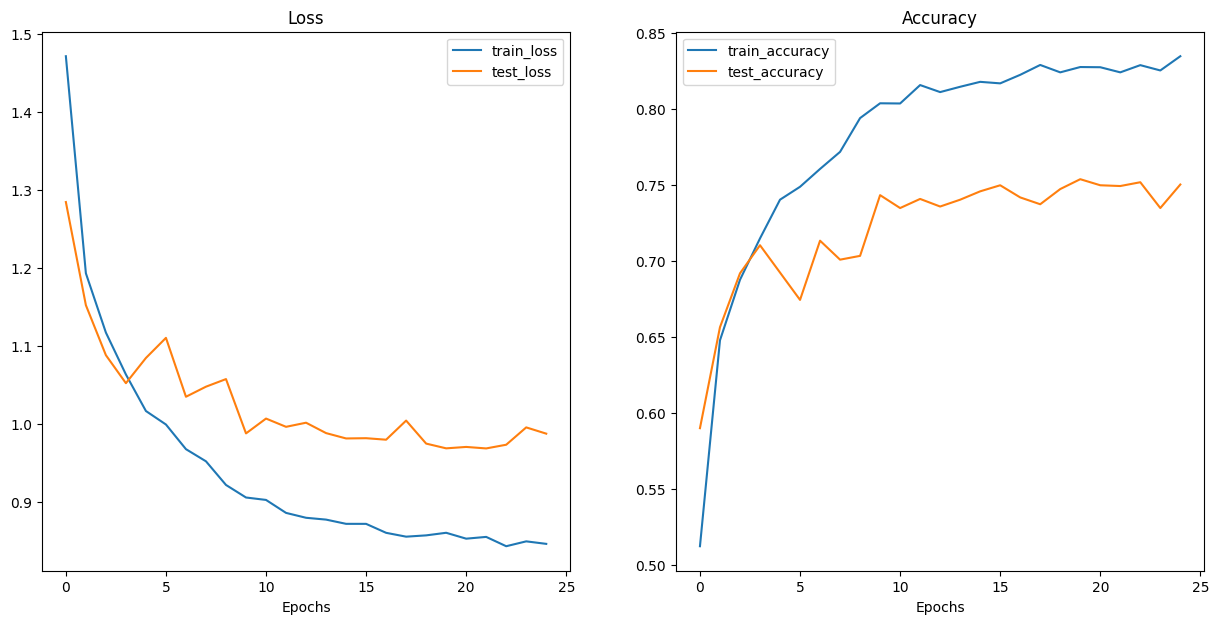

In [20]:
# Plot the stored loss/accuracy curves to inspect convergence.
fig = plot_loss_curves(results)
fig.show()
